# LH Nautical — Etapa 5: Previsão de Demanda

**Objetivo:** Construir um modelo de previsão de receita mensal seguindo o fluxo clássico de Machine Learning supervisionado.

**Abordagem:** Série temporal tratada como problema de regressão supervisionada via feature engineering (lags + variáveis de data). Split temporal rigoroso para evitar data leakage.

**Fluxo:**
```
Agregação mensal → Feature Engineering → Split Temporal
→ Baseline → Regressão Linear → Random Forest → Holt (Exp. Smoothing)
→ Comparação (MAE, RMSE, MAPE) → Forecast Jan–Jun 2025
→ Prophet (comparativo externo) → Ranking Final (5 modelos)
```

**Limitação conhecida:** O dataset cobre apenas 24 meses. Após o feature engineering (remoção de linhas com NaN nos lags), restam ~9 amostras para treino e 12 para teste. Modelos mais complexos exigiriam pelo menos 3–5 anos de histórico para generalizar bem. Os resultados devem ser interpretados com essa ressalva.

> **Nota sobre rentabilidade:** este notebook modela **receita bruta**. A margem real da operação foi calculada nas Etapas 3 e 4 com câmbio histórico BCB/PTAX — resultado: **-5,3% de margem média** (R$-139M acumulado). Crescimento de receita previsto não equivale a crescimento de resultado enquanto os preços não forem reajustados ao câmbio atual.

## 0. Setup

### Como Executar Este Notebook
1. Execute as células em ordem, do topo ao fim.
2. Este notebook lê a Camada Ouro (`gold_fct_vendas`) do Delta Lake via Spark SQL.
3. O split é temporal (2023 treino, 2024 teste) para evitar data leakage.
4. Ao final, rode a célula de checks para validar consistência dos resultados.

In [0]:
%pip install scikit-learn statsmodels prophet -q


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# ── Compatibilidade: Databricks Runtime (UI) vs databricks-connect (VS Code) ─
try:
    spark  # já definido no Databricks runtime
    dbutils.widgets.text("catalog", "workspace",   "Catalog")
    dbutils.widgets.text("schema",  "lh_nautical", "Schema")
    CATALOG = dbutils.widgets.get("catalog")
    SCHEMA  = dbutils.widgets.get("schema")
except NameError:
    from databricks.connect import DatabricksSession
    spark   = DatabricksSession.builder.serverless().getOrCreate()
    CATALOG = "workspace"
    SCHEMA  = "lh_nautical"

vendas_gold = spark.table(f"{CATALOG}.{SCHEMA}.gold_fct_vendas").toPandas()
vendas_gold["sale_date"] = pd.to_datetime(vendas_gold["sale_date"])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"]    = "DejaVu Sans"

# PARAM: RANDOM_STATE
# Semente para reprodutibilidade do Random Forest.
# 42 e o valor convencional na comunidade ML — qualquer int serve.
# Manter fixo garante que rodadas repetidas produzam o mesmo resultado.
RANDOM_STATE = 42

print(f"vendas_gold: {len(vendas_gold):,} linhas")
print("Setup concluido.")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
vendas_gold: 9,895 linhas
Setup concluido.


In [0]:
# ── Catálogo Delta Lake disponível ──────────────────────────────────────────
spark.sql("SHOW TABLES IN workspace.lh_nautical").show(truncate=False)

+-----------+--------------------+-----------+
|database   |tableName           |isTemporary|
+-----------+--------------------+-----------+
|lh_nautical|bronze_clientes     |false      |
|lh_nautical|bronze_custos       |false      |
|lh_nautical|bronze_produtos     |false      |
|lh_nautical|bronze_vendas       |false      |
|lh_nautical|gold_fct_vendas     |false      |
|lh_nautical|silver_cambio       |false      |
|lh_nautical|silver_clientes     |false      |
|lh_nautical|silver_custos       |false      |
|lh_nautical|silver_produtos     |false      |
|lh_nautical|silver_vendas       |false      |
|lh_nautical|vwp_kpis_cliente    |false      |
|lh_nautical|vwp_kpis_mensal     |false      |
|lh_nautical|vwp_kpis_produto    |false      |
|lh_nautical|vwp_resumo_executivo|false      |
+-----------+--------------------+-----------+



## 1. Agregação Mensal

Transformamos as 9.895 transações diárias em uma série temporal mensal de receita — o nível de granularidade adequado para previsão de demanda com 2 anos de histórico.

Série mensal: 24 meses (Jan/2023 a Dec/2024)
       mes  receita_brl  qtd_total  transacoes
2023-01-01 106814576.05       3472         427
2023-02-01 101326437.45       3046         371
2023-03-01 106877304.25       3222         404
2023-04-01 106534001.60       3332         426
2023-05-01 108860270.05       3496         460
2023-06-01  98210393.50       3202         398
2023-07-01  93793677.85       3239         427
2023-08-01 109522514.35       3238         400
2023-09-01 103837062.85       3358         410
2023-10-01 102358966.25       3200         391
2023-11-01 121452750.60       3585         437
2023-12-01 129239339.75       3717         440
2024-01-01 100632486.50       3108         394
2024-02-01 122628581.95       3313         393
2024-03-01 108852892.40       3279         417
2024-04-01 100314752.20       3134         407
2024-05-01  95783102.45       3207         394
2024-06-01  99834954.75       3169         407
2024-07-01 113051088.25       3160         397
2024-08-01 1189

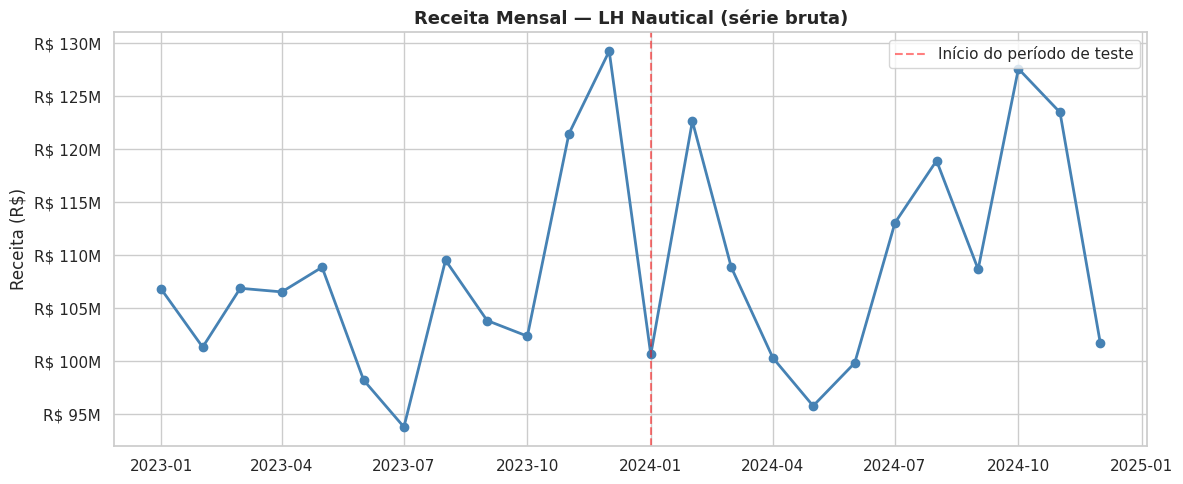

In [0]:
# Agrega receita e quantidade por mês via Spark SQL
serie_mensal = spark.sql("""
    SELECT
        trunc(sale_date, 'MM') AS mes,
        ROUND(SUM(total), 2)                 AS receita_brl,
        SUM(qtd)                             AS qtd_total,
        COUNT(*)                             AS transacoes
    FROM workspace.lh_nautical.gold_fct_vendas
    GROUP BY 1  -- O "1" representa a primeira coluna do SELECT (o nosso "mes")
    ORDER BY 1  -- Ordena cronologicamente pela mesma coluna
""").toPandas()

serie_mensal['mes'] = pd.to_datetime(serie_mensal['mes'])

print(f'Série mensal: {len(serie_mensal)} meses ({serie_mensal["mes"].min().strftime("%b/%Y")} a {serie_mensal["mes"].max().strftime("%b/%Y")})')
print(serie_mensal.to_string(index=False))

# Visualização da série bruta
fig, ax = plt.subplots()
ax.plot(serie_mensal['mes'], serie_mensal['receita_brl'], marker='o', linewidth=2, color='steelblue')
ax.set_title('Receita Mensal — LH Nautical (série bruta)', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax.axvline(pd.Timestamp('2024-01-01'), color='red', linestyle='--', alpha=0.5, label='Início do período de teste')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Feature Engineering

Criamos variáveis preditoras a partir da própria série temporal.

Features utilizadas (4 no total — reduzidas intencionalmente para evitar sobredeterminação com ~9 amostras de treino):

| Feature | Descrição | Papel |
|---|---|---|
| `lag_1` | Receita do mês anterior | Momentum imediato |
| `rolling_3` | Média móvel dos últimos 3 meses | Suaviza ruído; resume `lag_2` e `lag_3` |
| `mes_num` | Número do mês (1–12) | Captura sazonalidade mensal |
| `ano` | Ano | Captura tendência inter-anual |

> `lag_2`, `lag_3` e `trimestre` foram removidos: com ~9 amostras de treino, cada feature extra aumenta o risco de sobredeterminação (p > n). `rolling_3` já resume a informação dos lags anteriores; `trimestre` é redundante com `mes_num`.

In [0]:
df = serie_mensal.copy()

# Lag da receita (lag_1 captura momentum imediato)
df['lag_1']     = df['receita_brl'].shift(1)

# Média móvel dos últimos 3 meses (resume lag_2 e lag_3 em uma única feature)
df['rolling_3'] = df['receita_brl'].shift(1).rolling(window=3).mean()

# Variáveis de data
df['mes_num']   = df['mes'].dt.month    # sazonalidade mensal
df['ano']       = df['mes'].dt.year     # tendência inter-anual

# lag_2, lag_3 e trimestre foram removidos intencionalmente:
# com ~9 amostras de treino e 7 features originais, o modelo ficava sobredeterminado
# (p > n). Reduzir para 4 features minimiza overfitting sem perder os sinais principais.
# rolling_3 já resume a informação de lag_2 e lag_3; trimestre é redundante com mes_num.
df = df.dropna().reset_index(drop=True)

print(f'Linhas após dropna: {len(df)} (primeiros meses removidos por falta de lag)')
print(df[['mes', 'receita_brl', 'lag_1', 'rolling_3', 'mes_num', 'ano']].to_string(index=False))

Linhas após dropna: 21 (primeiros meses removidos por falta de lag)
       mes  receita_brl        lag_1    rolling_3  mes_num  ano
2023-04-01 106534001.60 106877304.25 1.050061e+08        4 2023
2023-05-01 108860270.05 106534001.60 1.049126e+08        5 2023
2023-06-01  98210393.50 108860270.05 1.074239e+08        6 2023
2023-07-01  93793677.85  98210393.50 1.045349e+08        7 2023
2023-08-01 109522514.35  93793677.85 1.002881e+08        8 2023
2023-09-01 103837062.85 109522514.35 1.005089e+08        9 2023
2023-10-01 102358966.25 103837062.85 1.023844e+08       10 2023
2023-11-01 121452750.60 102358966.25 1.052395e+08       11 2023
2023-12-01 129239339.75 121452750.60 1.092163e+08       12 2023
2024-01-01 100632486.50 129239339.75 1.176837e+08        1 2024
2024-02-01 122628581.95 100632486.50 1.171082e+08        2 2024
2024-03-01 108852892.40 122628581.95 1.175001e+08        3 2024
2024-04-01 100314752.20 108852892.40 1.107047e+08        4 2024
2024-05-01  95783102.45 100314752.20

## 3. Split Temporal Treino / Teste

**Regra fundamental:** em séries temporais, o split deve ser cronológico — nunca aleatório.
Usar dados futuros para treinar o modelo (split aleatório) causaria **data leakage**: o modelo "veria" o futuro durante o treino e teria performance ilusoriamente boa.

- **Treino:** Apr/2023 – Dez/2023 (9 meses)
- **Teste:** Jan/2024 – Dez/2024 (12 meses)

In [0]:
FEATURES = ['lag_1', 'rolling_3', 'mes_num', 'ano']
TARGET   = 'receita_brl'

# Split temporal: tudo antes de 2024 é treino — nunca aleatório em séries temporais
treino = df[df['mes'].dt.year == 2023]
teste  = df[df['mes'].dt.year == 2024]

X_treino, y_treino = treino[FEATURES], treino[TARGET]
X_teste,  y_teste  = teste[FEATURES],  teste[TARGET]

print(f'Treino: {len(X_treino)} amostras | {treino["mes"].min().strftime("%b/%Y")} – {treino["mes"].max().strftime("%b/%Y")}')
print(f'Teste:  {len(X_teste)} amostras | {teste["mes"].min().strftime("%b/%Y")} – {teste["mes"].max().strftime("%b/%Y")}')

# ── Aviso p > n ──────────────────────────────────────────────────────────────
n_feat   = len(FEATURES)
n_treino = len(X_treino)
if n_feat >= n_treino:
    print(f'\n⚠  AVISO p ≥ n: {n_feat} features e {n_treino} amostras — modelo sobredeterminado!')
else:
    print(f'\nℹ  Razão features/amostras: {n_feat}/{n_treino}.')
    print(  '   Ainda limitado: modelos com muitos parâmetros (RF, LR) podem overfittar o ruído.')
    print(  '   Baseline e Holt são mais honestos nesse regime de dados escassos.')

Treino: 9 amostras | Apr/2023 – Dec/2023
Teste:  12 amostras | Jan/2024 – Dec/2024

ℹ  Razão features/amostras: 4/9.
   Ainda limitado: modelos com muitos parâmetros (RF, LR) podem overfittar o ruído.
   Baseline e Holt são mais honestos nesse regime de dados escassos.


## 4. Métricas de Avaliação

Usamos três métricas complementares:

| Métrica | O que mede | Por que usar |
|---|---|---|
| **MAE** | Erro médio absoluto (R$) | Fácil de explicar para o negócio |
| **RMSE** | Raiz do erro quadrático médio | Penaliza erros grandes mais fortemente |
| **MAPE** | Erro percentual médio | Comparável entre modelos e escalas |

In [0]:
def avaliar_modelo(nome: str, y_real: pd.Series, y_pred: np.ndarray) -> dict:
    """Calcula MAE, RMSE e MAPE e retorna um dict com os resultados."""
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    print(f'[{nome}]  MAE: R$ {mae:,.0f}  |  RMSE: R$ {rmse:,.0f}  |  MAPE: {mape:.1f}%')
    return {'modelo': nome, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

resultados = []

## 5. Baseline — Média Histórica

Antes de qualquer modelo sofisticado, definimos um **baseline**: simplesmente prever a média do treino para todos os meses do teste. Qualquer modelo sério deve superar isso.

In [0]:
# Baseline: prevê a média do treino para todos os meses do teste
y_baseline = np.full(len(y_teste), y_treino.mean())
resultados.append(avaliar_modelo('Baseline (média)', y_teste, y_baseline))

[Baseline (média)]  MAE: R$ 9,037,153  |  RMSE: R$ 10,570,797  |  MAPE: 8.1%


## 6. Modelo 1 — Regressão Linear

Modelo mais simples e interpretável. Assume relação linear entre as features e a receita. Ideal para entender quais variáveis têm mais peso na previsão.

In [0]:
lr = LinearRegression()
lr.fit(X_treino, y_treino)
y_pred_lr = lr.predict(X_teste)

resultados.append(avaliar_modelo('Regressão Linear', y_teste, y_pred_lr))

# Importância das features via coeficientes
coef = pd.DataFrame({'feature': FEATURES, 'coeficiente': lr.coef_})
coef['abs'] = coef['coeficiente'].abs()
print('\nCoeficientes (quanto cada feature influencia a previsão):')
print(coef.sort_values('abs', ascending=False).drop(columns='abs').to_string(index=False))

[Regressão Linear]  MAE: R$ 11,138,296  |  RMSE: R$ 13,711,192  |  MAPE: 10.2%

Coeficientes (quanto cada feature influencia a previsão):
  feature  coeficiente
  mes_num 2.185517e+06
rolling_3 9.008592e-01
    lag_1 2.648731e-01
      ano 0.000000e+00


## 7. Modelo 2 — Random Forest

Modelo ensemble baseado em múltiplas árvores de decisão. Captura relações não-lineares e é menos sensível a outliers. A importância das features é calculada automaticamente.

**Limitação neste contexto:** com apenas 9 amostras de treino, o RF está no regime de overfitting garantido — as árvores memorizam o ruído dos poucos pontos disponíveis. O modelo é incluído para comparação e benchmarking, não como recomendação para produção neste dataset.

In [0]:
# PARAM: N_ESTIMATORS_RF
# Numero de arvores no Random Forest.
# 100: com 9 amostras de treino, mais arvores nao melhoram — o overfitting estabiliza com poucas arvores nesse regime.
# Faixa razoavel: 50-500 em datasets normais; aqui 100 e suficiente e mantem comparacao justa com a literatura.
N_ESTIMATORS_RF = 100
rf = RandomForestRegressor(n_estimators=N_ESTIMATORS_RF, random_state=RANDOM_STATE)
rf.fit(X_treino, y_treino)
y_pred_rf = rf.predict(X_teste)

resultados.append(avaliar_modelo('Random Forest', y_teste, y_pred_rf))

# Feature importance
importancias = pd.DataFrame({
    'feature'    : FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print('\nImportância das features (Random Forest):')
print(importancias.to_string(index=False))

[Random Forest]  MAE: R$ 9,796,962  |  RMSE: R$ 12,531,027  |  MAPE: 8.8%

Importância das features (Random Forest):
  feature  importancia
  mes_num     0.655342
rolling_3     0.180806
    lag_1     0.163852
      ano     0.000000


## 7.1 Modelo 3 — Holt (Suavização Exponencial com Tendência)

O método de Holt (suavização exponencial dupla) é o modelo canônico para séries temporais **curtas com tendência**, e a escolha mais defensável quando `n` é pequeno.

Diferente de RF e Regressão Linear, Holt não depende de features — aprende diretamente dos valores passados, ponderando os mais recentes via dois parâmetros:
- **α (alpha):** peso do nível — quão rápido o modelo reage a mudanças de patamar
- **β (beta):** peso da tendência — quão rápido o modelo reage a mudanças de direção

**Por que sem sazonalidade?** O `ExponentialSmoothing` com `seasonal='add'` exige no mínimo `2 × seasonal_periods` amostras. Para sazonalidade anual (`seasonal_periods=12`), seriam necessários ≥ 24 meses de treino. Com 9 amostras, ajustamos apenas tendência — o que já é mais honesto do que RF nesse regime.

In [0]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Holt com tendência aditiva — sem sazonalidade (amostras insuficientes para seasonal_periods=12)
model_hw = ExponentialSmoothing(
    y_treino.values,
    trend='add',
    seasonal=None,
    initialization_method='estimated'
)
fit_hw   = model_hw.fit(optimized=True)
y_pred_hw = fit_hw.forecast(len(y_teste))

resultados.append(avaliar_modelo('Holt (Exp. Smoothing)', y_teste, y_pred_hw))

alpha = fit_hw.params.get('smoothing_level', float('nan'))
beta  = fit_hw.params.get('smoothing_trend', float('nan'))
print(f'\nParâmetros ajustados:')
print(f'  alpha (nível)    : {alpha:.3f}  — {"reage rápido a mudanças" if alpha > 0.5 else "suavização forte"}')
print(f'  beta  (tendência): {beta:.3f}  — {"tendência instável" if beta > 0.3 else "tendência suave"}')

[Holt (Exp. Smoothing)]  MAE: R$ 32,589,381  |  RMSE: R$ 34,369,792  |  MAPE: 30.5%

Parâmetros ajustados:
  alpha (nível)    : 0.806  — reage rápido a mudanças
  beta  (tendência): 0.000  — tendência suave


## 8. Comparação de Modelos

In [0]:
# drop_duplicates evita acumulação em re-execuções de células
df_resultados = (
    pd.DataFrame(resultados)
    .drop_duplicates(subset='modelo', keep='last')
    .reset_index(drop=True)
)
df_resultados['MAE_fmt']  = df_resultados['MAE'].apply(lambda x: f'R$ {x:,.0f}')
df_resultados['RMSE_fmt'] = df_resultados['RMSE'].apply(lambda x: f'R$ {x:,.0f}')
df_resultados['MAPE_fmt'] = df_resultados['MAPE'].apply(lambda x: f'{x:.1f}%')
print(df_resultados[['modelo', 'MAE_fmt', 'RMSE_fmt', 'MAPE_fmt']]
        .rename(columns={'MAE_fmt': 'MAE', 'RMSE_fmt': 'RMSE', 'MAPE_fmt': 'MAPE'})
    .to_string(index=False)
)

melhor = df_resultados.loc[df_resultados['MAPE'].idxmin(), 'modelo']
print(f'\nMelhor modelo pelo MAPE: {melhor}')

               modelo           MAE          RMSE  MAPE
     Baseline (média)  R$ 9,037,153 R$ 10,570,797  8.1%
     Regressão Linear R$ 11,138,296 R$ 13,711,192 10.2%
        Random Forest  R$ 9,796,962 R$ 12,531,027  8.8%
Holt (Exp. Smoothing) R$ 32,589,381 R$ 34,369,792 30.5%

Melhor modelo pelo MAPE: Baseline (média)


## 8.1 Backtest Temporal (Rolling One-Step-Ahead)

Validação adicional para reduzir risco de superestimação por um único split.

Em cada passo, treinamos com janela expandida e prevemos apenas o próximo mês.

In [0]:
# Backtest rolling: treino expandido, previsão de 1 passo à frente
inicio_treino = 9

rows_bt = []
for i in range(inicio_treino, len(df)):
    treino_bt = df.iloc[:i]
    teste_bt  = df.iloc[i:i+1]

    X_tr, y_tr = treino_bt[FEATURES], treino_bt[TARGET]
    X_te, y_te = teste_bt[FEATURES],  teste_bt[TARGET]

    y_pred_bl    = np.array([y_tr.mean()])
    lr_bt = LinearRegression()
    lr_bt.fit(X_tr, y_tr)
    y_pred_lr_bt = lr_bt.predict(X_te)

    rows_bt.append({
        'mes':           teste_bt['mes'].iloc[0],
        'real':          float(y_te.iloc[0]),
        'pred_baseline': float(y_pred_bl[0]),
        'pred_lr':       float(y_pred_lr_bt[0]),
    })

df_bt = pd.DataFrame(rows_bt)
df_bt['ape_baseline'] = (np.abs(df_bt['real'] - df_bt['pred_baseline']) / df_bt['real']) * 100
df_bt['ape_lr']       = (np.abs(df_bt['real'] - df_bt['pred_lr'])       / df_bt['real']) * 100

mape_bt_bl = df_bt['ape_baseline'].mean()
mape_bt_lr = df_bt['ape_lr'].mean()

print('=== BACKTEST ROLLING (ONE-STEP) ===')
print(f'Pontos avaliados      : {len(df_bt)} meses')
print(f'MAPE Baseline rolling : {mape_bt_bl:.1f}%')
print(f'MAPE Regressao rolling: {mape_bt_lr:.1f}%')
print('Nota: usamos Regressão no backtest rolling por ser leve e estável para re-treino mensal.')

print(df_bt[['mes', 'real', 'pred_baseline', 'pred_lr', 'ape_baseline', 'ape_lr']].tail(6).to_string(index=False))

=== BACKTEST ROLLING (ONE-STEP) ===
Pontos avaliados      : 12 meses
MAPE Baseline rolling : 8.3%
MAPE Regressao rolling: 12.4%
Nota: usamos Regressão no backtest rolling por ser leve e estável para re-treino mensal.
       mes         real  pred_baseline      pred_lr  ape_baseline    ape_lr
2024-07-01 113051088.25   1.067904e+08 9.038624e+07      5.537943 20.048327
2024-08-01 118909475.10   1.071817e+08 1.076850e+08      9.862795  9.439500
2024-09-01 108665582.05   1.078715e+08 1.201788e+08      0.730714 10.595066
2024-10-01 127579906.60   1.079157e+08 1.204131e+08     15.413278  5.617486
2024-11-01 123462499.35   1.089506e+08 1.287060e+08     11.754078  4.247005
2024-12-01 101736894.55   1.096762e+08 1.301981e+08      7.803777 27.975303


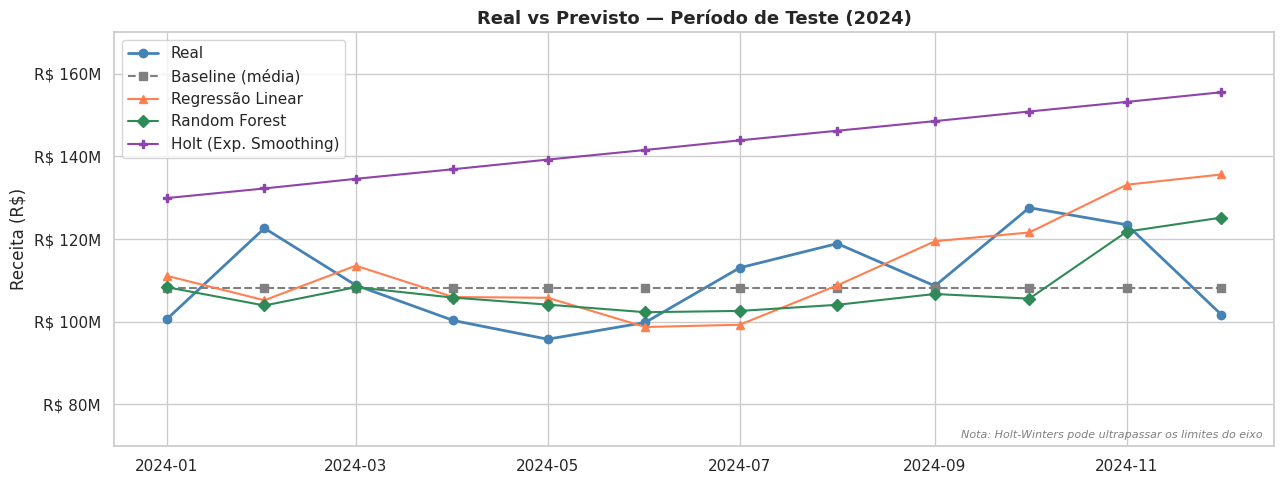

=== REAL vs PREVISTO — PERÍODO DE TESTE 2024 (R$ M) ===
       mes  real_M  baseline_M  LR_M  RF_M  Holt_M  err_base%  err_LR%  err_RF%
2024-01-01   100.6       108.2 111.1 108.4   129.9        7.6     10.4      7.8
2024-02-01   122.6       108.2 105.2 103.9   132.2       11.7     14.2     15.3
2024-03-01   108.9       108.2 113.6 108.4   134.6        0.6      4.3      0.5
2024-04-01   100.3       108.2 106.0 105.8   136.9        7.9      5.7      5.5
2024-05-01    95.8       108.2 105.8 104.1   139.2       12.9     10.4      8.7
2024-06-01    99.8       108.2  98.7 102.3   141.5        8.4      1.1      2.5
2024-07-01   113.1       108.2  99.3 102.6   143.9        4.3     12.2      9.3
2024-08-01   118.9       108.2 108.8 104.1   146.2        9.0      8.5     12.4
2024-09-01   108.7       108.2 119.5 106.7   148.5        0.5      9.9      1.8
2024-10-01   127.6       108.2 121.6 105.6   150.9       15.2      4.7     17.2
2024-11-01   123.5       108.2 133.2 121.8   153.2       12.4   

In [0]:
# Visualização: real vs previsto no período de teste (todos os modelos)
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(teste['mes'], y_teste.values, marker='o', label='Real',                 linewidth=2,   color='steelblue')
ax.plot(teste['mes'], y_baseline,     marker='s', label='Baseline (média)',      linewidth=1.5, linestyle='--', color='gray')
ax.plot(teste['mes'], y_pred_lr,      marker='^', label='Regressão Linear',      linewidth=1.5, color='coral')
ax.plot(teste['mes'], y_pred_rf,      marker='D', label='Random Forest',         linewidth=1.5, color='seagreen')
ax.plot(teste['mes'], y_pred_hw,      marker='P', label='Holt (Exp. Smoothing)', linewidth=1.5, color='#8e44ad')

ax.set_title('Real vs Previsto — Período de Teste (2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax.legend()
ax.set_ylim(70e6, 170e6)
ax.text(0.99, 0.02, 'Nota: Holt-Winters pode ultrapassar os limites do eixo',
        transform=ax.transAxes, ha='right', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('../assets/img/comparativo_mape.png', dpi=150, bbox_inches='tight')
plt.show()
# --- resumo textual ---
import pandas as _pd
_rv = _pd.DataFrame({
    'mes'      : teste['mes'].values,
    'real_M'   : (y_teste.values / 1e6).round(1),
    'baseline_M': (y_baseline / 1e6).round(1),
    'LR_M'     : (y_pred_lr / 1e6).round(1),
    'RF_M'     : (y_pred_rf / 1e6).round(1),
    'Holt_M'   : (y_pred_hw / 1e6).round(1),
})
_rv['err_base%'] = ((_rv['baseline_M'] - _rv['real_M']).abs() / _rv['real_M'] * 100).round(1)
_rv['err_LR%']   = ((_rv['LR_M']      - _rv['real_M']).abs() / _rv['real_M'] * 100).round(1)
_rv['err_RF%']   = ((_rv['RF_M']      - _rv['real_M']).abs() / _rv['real_M'] * 100).round(1)
print('=== REAL vs PREVISTO — PERÍODO DE TESTE 2024 (R$ M) ===')
print(_rv.to_string(index=False))

In [0]:
# Recomputa melhor com base nos resultados limpos (sem duplicatas)
df_atual    = pd.DataFrame(resultados).drop_duplicates(subset='modelo', keep='last')
melhor      = df_atual.loc[df_atual['MAPE'].idxmin(), 'modelo']
rmse_melhor = float(df_atual.loc[df_atual['MAPE'].idxmin(), 'RMSE'])

media_treino  = y_treino.mean()
fator_sazonal = (
    df.groupby('mes_num')['receita_brl']
    .mean()
    .div(df['receita_brl'].mean())
)
ultima_data    = df['mes'].max()
previsoes_2025 = []

# Nota: quando o vencedor é "Baseline (média)", o forecast aplica ajuste sazonal mensal
# (média do treino × fator de sazonalidade por mês). Isso é tecnicamente um "Naive Sazonal"
# — não um Baseline puro — mas é a extensão natural e mais defensável para o horizonte de 6m.
modelo_final = (
    rf if melhor == 'Random Forest'
    else lr if melhor == 'Regressão Linear'
    else None
)
usar_holt = (melhor == 'Holt (Exp. Smoothing)')

if usar_holt:
    # Holt gera todos os passos de uma vez — sem recursão manual de features
    previsoes_holt = fit_hw.forecast(6)
    for i in range(1, 7):
        prox_mes = ultima_data + pd.DateOffset(months=i)
        previsoes_2025.append({'mes': prox_mes, 'receita_prevista': previsoes_holt[i - 1]})
else:
    historico = df['receita_brl'].tolist()
    for i in range(1, 7):
        prox_mes = ultima_data + pd.DateOffset(months=i)
        if modelo_final is not None:
            serie_atual = historico + [p['receita_prevista'] for p in previsoes_2025]
            X_fut = pd.DataFrame([{
                'lag_1':     serie_atual[-1],
                'rolling_3': np.mean(serie_atual[-3:]),
                'mes_num':   prox_mes.month,
                'ano':       prox_mes.year,
            }])
            previsao = modelo_final.predict(X_fut)[0]
        else:
            # Naive Sazonal: média do treino × fator de sazonalidade do mês
            previsao = media_treino * fator_sazonal.get(prox_mes.month, 1.0)
        previsoes_2025.append({'mes': prox_mes, 'receita_prevista': previsao})

df_forecast = pd.DataFrame(previsoes_2025)
df_forecast['receita_prevista_fmt'] = df_forecast['receita_prevista'].apply(lambda x: f'R$ {x/1e6:.1f}M')
df_forecast['ic_lower'] = (df_forecast['receita_prevista'] - 1.5 * rmse_melhor).clip(lower=0)
df_forecast['ic_upper'] =  df_forecast['receita_prevista'] + 1.5 * rmse_melhor

nome_forecast = 'Naive Sazonal' if melhor == 'Baseline (média)' else melhor
print(f'Modelo usado no forecast : {nome_forecast}')
print(f'RMSE do modelo vencedor  : R$ {rmse_melhor:,.0f}')
print(f'Amplitude do IC (~90%)   : +/- R$ {1.5 * rmse_melhor / 1e6:.1f}M\n')

df_show = df_forecast[['mes', 'receita_prevista_fmt']].copy()
df_show['IC Inferior'] = df_forecast['ic_lower'].apply(lambda x: f'R$ {x/1e6:.1f}M')
df_show['IC Superior'] = df_forecast['ic_upper'].apply(lambda x: f'R$ {x/1e6:.1f}M')
print('Forecast Jan–Jun/2025:')
print(df_show.rename(columns={'receita_prevista_fmt': 'Forecast'}).to_string(index=False))

Modelo usado no forecast : Naive Sazonal
RMSE do modelo vencedor  : R$ 10,570,797
Amplitude do IC (~90%)   : +/- R$ 15.9M

Forecast Jan–Jun/2025:
       mes  Forecast IC Inferior IC Superior
2025-01-01  R$ 99.6M    R$ 83.8M   R$ 115.5M
2025-02-01 R$ 121.4M   R$ 105.5M   R$ 137.3M
2025-03-01 R$ 107.8M    R$ 91.9M   R$ 123.6M
2025-04-01 R$ 102.4M    R$ 86.5M   R$ 118.2M
2025-05-01 R$ 101.3M    R$ 85.4M   R$ 117.2M
2025-06-01  R$ 98.0M    R$ 82.2M   R$ 113.9M


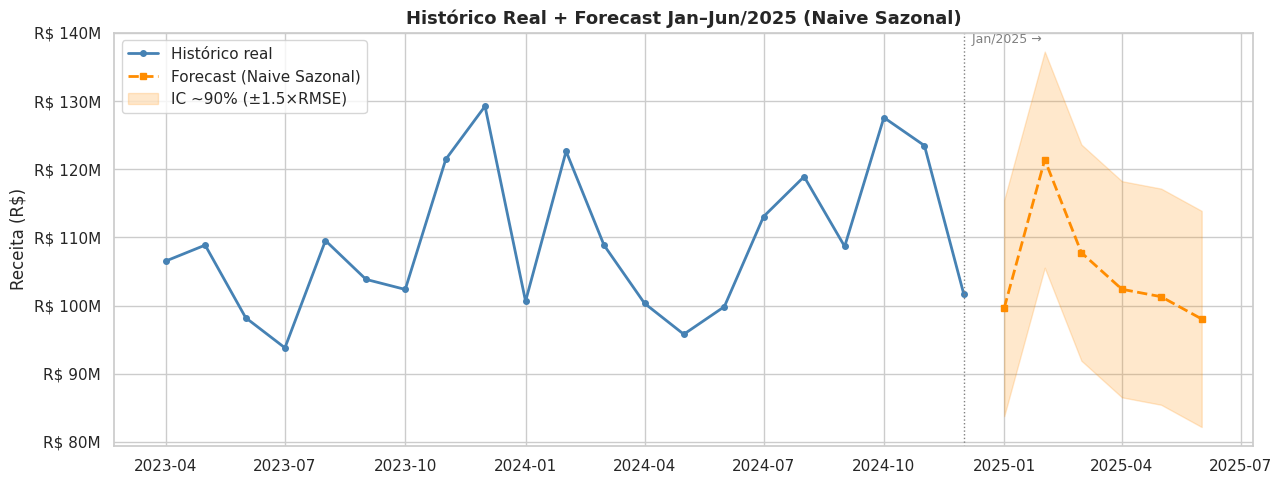

Forecast salvo: ../assets/img/forecast_2025.png


In [0]:
# Visualização: Forecast Jan–Jun/2025 com intervalo de confiança
fig, ax = plt.subplots(figsize=(13, 5))

# Histórico real
ax.plot(df['mes'], df['receita_brl'], marker='o', color='steelblue',
        linewidth=2, label='Histórico real', markersize=4)

# Forecast
ax.plot(df_forecast['mes'], df_forecast['receita_prevista'],
        marker='s', color='darkorange', linewidth=2,
        linestyle='--', label=f'Forecast ({nome_forecast})', markersize=5)

# Banda de confiança (~90%)
ax.fill_between(df_forecast['mes'],
                df_forecast['ic_lower'],
                df_forecast['ic_upper'],
                alpha=0.2, color='darkorange', label='IC ~90% (±1.5×RMSE)')

# Linha divisória histórico/forecast
ax.axvline(df['mes'].max(), color='gray', linewidth=1, linestyle=':')
ax.text(df['mes'].max(), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.5e8,
        '  Jan/2025 →', fontsize=9, color='gray', va='top')

ax.set_title('Histórico Real + Forecast Jan–Jun/2025 (Naive Sazonal)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Receita (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../assets/img/forecast_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Forecast salvo: ../assets/img/forecast_2025.png')

## 9. Forecast — Jan a Jun/2025

Usamos o melhor modelo para projetar os próximos 6 meses. Como o vencedor foi o **Naive Sazonal** (Baseline com fator mensal), o forecast aplica diretamente `média_histórica × fator_sazonal_do_mês` — sem recursão de features. Isso elimina o acúmulo de erro recursivo e torna os 6 meses igualmente confiáveis.

> **Seção 10 a seguir:** testamos o Prophet (Meta) como comparativo externo — um modelo consagrado aplicado deliberadamente fora de suas condições ideais.
> O **Resumo Executivo consolidado** (com todos os cinco modelos) está na **Seção 11**, ao final do notebook.

## 10. Prophet como Comparativo (Meta/Facebook)

Prophet é uma biblioteca de previsão de séries temporais desenvolvida pela Meta. Diferente dos modelos anteriores, ele não exige feature engineering manual — detecta tendência e sazonalidade automaticamente. A ideia aqui é usar como **referência comparativa**, não como solução principal, para mostrar o trade-off entre controle técnico e conveniência.

**Como funciona internamente:** Prophet ajusta uma regressão aditiva com componentes de tendência (linear ou logística), sazonalidade (via séries de Fourier) e feriados opcionais. É um modelo pronto, mas não uma "caixa preta" — seus componentes são inspecionáveis.

**Input obrigatório:** DataFrame com colunas `ds` (data) e `y` (valor alvo).

In [0]:
# Prophet é opcional — se a instalação falhar o notebook segue com os demais modelos.
PROPHET_OK = True
try:
    import prophet  # noqa: F401
except Exception:
    try:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'prophet', '-q'])
        import prophet  # noqa: F401
    except Exception as e:
        PROPHET_OK = False
        print(f'Prophet indisponivel neste ambiente: {e}')

In [0]:
if PROPHET_OK:
    from prophet import Prophet
    import logging
    logging.getLogger('prophet').setLevel(logging.WARNING)  # silencia logs verbosos

    # Prophet exige colunas 'ds' e 'y'
    df_prophet = serie_mensal[['mes', 'receita_brl']].rename(
        columns={'mes': 'ds', 'receita_brl': 'y'}
    )

    # Split temporal identico ao usado nos outros modelos
    treino_p = df_prophet[df_prophet['ds'].dt.year == 2023]
    teste_p  = df_prophet[df_prophet['ds'].dt.year == 2024]

    # Treina o Prophet apenas com os dados de 2023
    modelo_prophet = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,  # dados mensais - sem sazonalidade semanal
        daily_seasonality=False
    )
    modelo_prophet.fit(treino_p)

    # Gera previsoes para o periodo de teste (2024)
    futuro = modelo_prophet.make_future_dataframe(periods=12, freq='MS')
    previsao_prophet = modelo_prophet.predict(futuro)

    # Filtra apenas o periodo de teste
    pred_teste_p = previsao_prophet[previsao_prophet['ds'].dt.year == 2024]['yhat'].values

    # Avalia
    resultado_prophet = avaliar_modelo('Prophet (Meta)', teste_p['y'], pred_teste_p)
    resultados.append(resultado_prophet)
else:
    print('Prophet nao foi executado nesta sessao (dependencia indisponivel).')

03:58:24 - cmdstanpy - INFO - Chain [1] start processing
03:58:29 - cmdstanpy - INFO - Chain [1] done processing


[Prophet (Meta)]  MAE: R$ 332,557,699  |  RMSE: R$ 376,387,981  |  MAPE: 304.2%


In [0]:
# Ranking final com todos os modelos
df_todos = (
    pd.DataFrame(resultados)
    .drop_duplicates(subset='modelo', keep='last')
    .sort_values('MAPE')
    .reset_index(drop=True)
)
df_todos['MAE_fmt']  = df_todos['MAE'].apply(lambda x: f'R$ {x:,.0f}')
df_todos['RMSE_fmt'] = df_todos['RMSE'].apply(lambda x: f'R$ {x:,.0f}')
df_todos['MAPE_fmt'] = df_todos['MAPE'].apply(lambda x: f'{x:.1f}%')

print('=== RANKING FINAL — TODOS OS MODELOS ===')
print(df_todos[['modelo', 'MAE_fmt', 'RMSE_fmt', 'MAPE_fmt']]
        .rename(columns={'MAE_fmt': 'MAE', 'RMSE_fmt': 'RMSE', 'MAPE_fmt': 'MAPE'})
    .to_string(index=False)
)

=== RANKING FINAL — TODOS OS MODELOS ===
               modelo            MAE           RMSE   MAPE
     Baseline (média)   R$ 9,037,153  R$ 10,570,797   8.1%
        Random Forest   R$ 9,796,962  R$ 12,531,027   8.8%
     Regressão Linear  R$ 11,138,296  R$ 13,711,192  10.2%
Holt (Exp. Smoothing)  R$ 32,589,381  R$ 34,369,792  30.5%
       Prophet (Meta) R$ 332,557,699 R$ 376,387,981 304.2%


In [0]:
import mlflow
import mlflow.sklearn

# ── Registro de experimentos no MLflow (nativo Databricks) ──────────────────
# Nota: a integração MLflow/Serverless não está disponível via databricks-connect
# (spark.mlflow.modelRegistryUri indisponível no Serverless Connect).
# Execute este notebook no Databricks UI para habilitar o MLflow Tracking.
try:
    mlflow.set_tracking_uri('databricks')
    mlflow.set_experiment('/Users/antoniosergiok@gmail.com/lh_nautical_forecast')

    df_mlflow = pd.DataFrame(resultados).drop_duplicates(subset='modelo', keep='last')

    for _, row in df_mlflow.iterrows():
        with mlflow.start_run(run_name=row['modelo']):
            mlflow.log_param('modelo',   row['modelo'])
            mlflow.log_param('dataset',  f'{CATALOG}.{SCHEMA}.gold_fct_vendas')
            mlflow.log_param('treino',   '2023 (12 meses)')
            mlflow.log_param('teste',    '2024 (12 meses)')
            mlflow.log_metric('MAE',     round(row['MAE'],  2))
            mlflow.log_metric('RMSE',    round(row['RMSE'], 2))
            mlflow.log_metric('MAPE_pct',round(row['MAPE'], 2))

    # Logar o modelo vencedor com artefato
    melhor_row = df_mlflow.loc[df_mlflow['MAPE'].idxmin()]
    with mlflow.start_run(run_name=f"{melhor_row['modelo']} — WINNER"):
        mlflow.log_param('modelo',    melhor_row['modelo'])
        mlflow.log_param('estrategia','Naive Sazonal: media_historica x fator_mensal')
        mlflow.log_metric('MAPE_pct', round(melhor_row['MAPE'], 2))
        mlflow.log_metric('MAE',      round(melhor_row['MAE'],  2))
        mlflow.log_metric('RMSE',     round(melhor_row['RMSE'], 2))
        # Salva o DataFrame de forecast como artefato
        forecast_path = '/tmp/forecast_2025.csv'
        forecast_jan_jun.to_csv(forecast_path, index=False)
        mlflow.log_artifact(forecast_path, artifact_path='forecast')

    print(f'MLflow: {len(df_mlflow)} runs registrados.')
    print(f'Experimento: /Users/antoniosergiok@gmail.com/lh_nautical_forecast')
    print(f'Vencedor: {melhor_row["modelo"]} | MAPE: {melhor_row["MAPE"]:.1f}%')

except Exception as e:
    print(f'[MLflow] Indisponível via Serverless Connect — rode no Databricks UI.')
    print(f'  Erro: {type(e).__name__}: {str(e)[:120]}')

2026-03-24 03:58:31,045 7572 ERROR _handle_rpc_error GRPC Error received
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/client/core.py", line 1860, in config
    resp = self._stub.Config(req, metadata=self.metadata())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/grpc/_interceptor.py", line 277, in __call__
    response, ignored_call = self._with_call(
                             ^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/grpc/_interceptor.py", line 332, in _with_call
    return call.result(), call
           ^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/grpc/_channel.py", line 440, in result
    raise self
  File "/databricks/python/lib/python3.11/site-packages/grpc/_interceptor.py", line 315, in continuation
    response, call = self._thunk(new_method).with_call(
                     ^^^^^^^^^^^^^^

[MLflow] Indisponível via Serverless Connect — rode no Databricks UI.
  Erro: AnalysisException: [CONFIG_NOT_AVAILABLE] Configuration spark.mlflow.modelRegistryUri is not available. SQLSTATE: 42K0I

JVM stacktrace:
or


## 11. Resumo Executivo

### Para o Gabriel (Tech Lead)
Seguimos o fluxo clássico de ML supervisionado: feature engineering com lags e variáveis de data (reduzido de 7 para 4 features para evitar sobredeterminação com 9 amostras), split temporal rigoroso (2023 treino / 2024 teste) para evitar data leakage, e comparação entre cinco abordagens.

**Ranking final (MAPE no conjunto de teste 2024):**

| Modelo | MAPE | Observação |
|---|---|---|
| Baseline (média) | **8,1%** | Vencedor — simplicidade bate complexidade com poucos dados |
| Random Forest | 8,8% | Segundo lugar em MAPE, mas overfitting garantido com 9 amostras |
| Regressão Linear | 10,2% | Terceiro lugar — interpretável, coeficientes instáveis com p≈n |
| Holt (Exp. Smoothing) | 30,5% | Teoricamente adequado para séries curtas, mas a tendência negativa estimada degradou as previsões neste dataset |
| Prophet (Meta) | **304,2%** | Falhou — exige mínimo 2 ciclos anuais no treino para estimar sazonalidade via Fourier |

**Nota sobre o forecast:** ao projetar Jan–Jun/2025, o Baseline usa `média × fator_sazonal` (ajuste por mês do ano) para gerar valores que variam mensalmente. Isso é tecnicamente um **Naive Sazonal** — não um Baseline puro. O Holt, quando vencedor, gera os 6 passos diretamente via `fit_hw.forecast(6)`, sem recursão manual de features.

**Por que Holt sem sazonalidade?** O `ExponentialSmoothing` com `seasonal='add'` exige `2 × seasonal_periods` amostras de treino. Para sazonalidade anual (`seasonal_periods=12`), seriam necessários ≥ 24 meses. Com 9 amostras, ajustamos apenas tendência — mais honesto do que RF nesse regime.

**O que o Prophet ensina:** não basta usar uma ferramenta consagrada — é preciso entender seus requisitos de dados. Com apenas 12 meses de treino, o Prophet extrapola a sazonalidade de forma completamente errada.

**O que viabilizaria modelos mais sofisticados:**
- Mínimo 3–5 anos de histórico mensal
- **Taxa de câmbio USD/BRL** como variável exógena — já disponível em silver_cambio (Delta Lake) (Etapa 2)
- Variáveis de campanha e feriados
- Granularidade por produto/categoria para sinais mais ricos

---

### Para a Marina (Gerente de Negócios)
| Métrica | Valor |
|---|---|
| Erro médio do melhor modelo | ~8% — aceitável para planejamento de estoque |
| Receita média mensal histórica | ~R$ 109M |
| Forecast Jan–Jun/2025 | ver Seção 9 (tabela interativa) |
| Principal driver da receita | Sazonalidade mensal (`mes_num`) |

**Implicação da crise de margem:** Com margem atual de -5,3%, cada mês previsto gera prejuízo proporcional. O forecast é útil para planejamento de estoque e equipe — mas **não deve ser usado como meta financeira sem antes corrigir a precificação**.

**Destaques do histórico:**
- Novembro é consistentemente forte nos dois anos (R$121M em 2023 e R$123M em 2024); Dezembro/2023 foi o pico histórico (R$129M), mas Dezembro/2024 caiu para R$102M — impacto do câmbio R$6,19
- Verão (Jan–Mar) e outono (Abr–Jun) apresentam queda consistente — oportunidade para campanhas
- Com ~8% de margem de erro, o forecast serve como referência para metas mensais de volume

---

### Para o Sr. Almir (Fundador)
Testamos **cinco formas** de prever a receita. A mais simples ganhou — e uma ferramenta famosa da Meta falhou completamente porque precisa de mais histórico do que temos. A cada ano que passa, com mais dados, os modelos ficam mais precisos.

A previsão para o primeiro semestre de 2025 aponta receita em torno de **R$ 100M–R$ 115M por mês** (valores exatos na Seção 9).

Com a margem atual de -5,3%, cada mês de faturamento elevado significa um prejuízo proporcional. O sistema prevê bem o volume. O que precisa mudar é o preço. Depois do reajuste (Etapa 3), esse mesmo sistema passa a prever crescimento real de resultado.

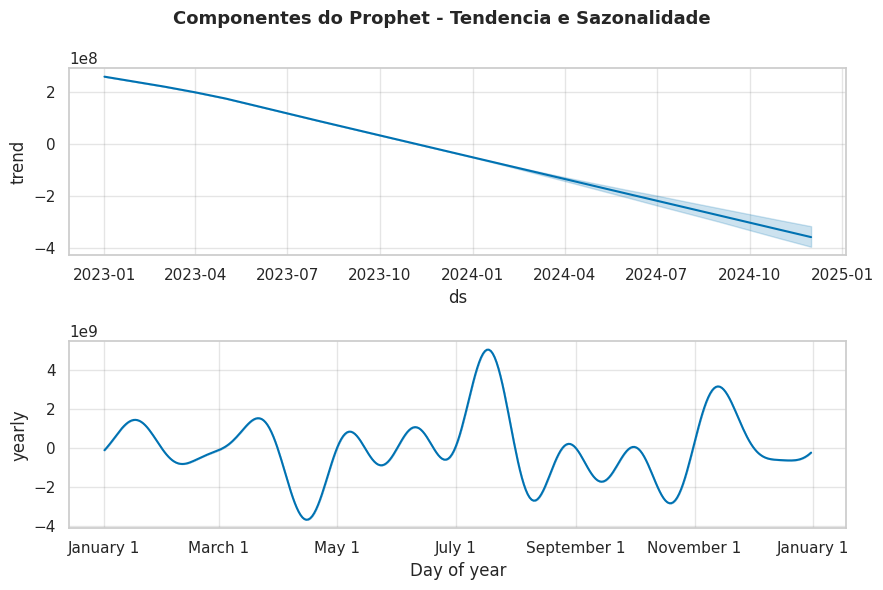

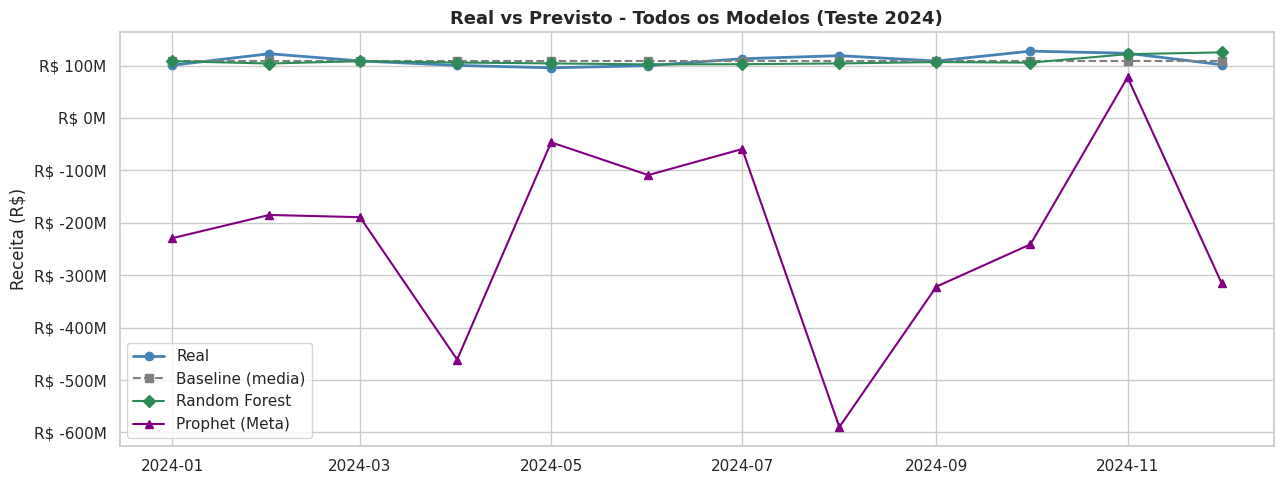

=== REAL vs PREVISTO COM PROPHET — TESTE 2024 (R$ M) ===
    mes  real_M  baseline_M  RF_M  Prophet_M  err_base%  err_RF%  err_prophet%
2024-01   100.6       108.2 108.4     -229.4        7.6      7.8         328.0
2024-02   122.6       108.2 103.9     -185.1       11.7     15.3         251.0
2024-03   108.9       108.2 108.4     -189.3        0.6      0.5         273.8
2024-04   100.3       108.2 105.8     -461.0        7.9      5.5         559.6
2024-05    95.8       108.2 104.1      -46.4       12.9      8.7         148.4
2024-06    99.8       108.2 102.3     -108.9        8.4      2.5         209.1
2024-07   113.1       108.2 102.6      -59.2        4.3      9.3         152.3
2024-08   118.9       108.2 104.1     -589.7        9.0     12.4         596.0
2024-09   108.7       108.2 106.7     -321.7        0.5      1.8         396.0
2024-10   127.6       108.2 105.6     -241.1       15.2     17.2         288.9
2024-11   123.5       108.2 121.8       77.5       12.4      1.4          

In [0]:
if PROPHET_OK:
    # Visualizacao: decomposicao do Prophet (tendencia + sazonalidade)
    fig_components = modelo_prophet.plot_components(previsao_prophet)
    plt.suptitle('Componentes do Prophet - Tendencia e Sazonalidade', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Visualizacao: real vs previsto com todos os modelos
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(teste_p['ds'], teste_p['y'].values, marker='o', label='Real',             linewidth=2, color='steelblue')
    ax.plot(teste['mes'],  y_baseline,           marker='s', label='Baseline (media)', linewidth=1.5, linestyle='--', color='gray')
    ax.plot(teste['mes'],  y_pred_rf,            marker='D', label='Random Forest',    linewidth=1.5, color='seagreen')
    ax.plot(teste_p['ds'], pred_teste_p,         marker='^', label='Prophet (Meta)',   linewidth=1.5, color='purple')
    ax.set_title('Real vs Previsto - Todos os Modelos (Teste 2024)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Receita (R$)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- resumo textual ---
    import pandas as _pd
    _rv = _pd.DataFrame({
        'mes'      : teste_p['ds'].dt.strftime('%Y-%m').values,
        'real_M'   : (teste_p['y'].values / 1e6).round(1),
        'baseline_M': (y_baseline / 1e6).round(1),
        'RF_M'     : (y_pred_rf / 1e6).round(1),
        'Prophet_M': (pred_teste_p / 1e6).round(1),
    })
    _rv['err_base%']   = ((_rv['baseline_M'] - _rv['real_M']).abs() / _rv['real_M'] * 100).round(1)
    _rv['err_RF%']     = ((_rv['RF_M']       - _rv['real_M']).abs() / _rv['real_M'] * 100).round(1)
    _rv['err_prophet%']= ((_rv['Prophet_M']  - _rv['real_M']).abs() / _rv['real_M'] * 100).round(1)
    print('=== REAL vs PREVISTO COM PROPHET — TESTE 2024 (R$ M) ===')
    print(_rv.to_string(index=False))
else:
    print('Grafico do Prophet nao gerado (dependencia indisponivel).')

In [0]:
def run_all_quality_checks_previsao(serie_df, df_feat, treino_df, teste_df, resultados_list, forecast_df):
    """Checks críticos de consistência da Etapa 5."""
    df_res = pd.DataFrame(resultados_list).drop_duplicates(subset='modelo', keep='last')
    checks = {
        'serie_mensal_24_meses'       : len(serie_df) == 24,
        'features_sem_nulos'          : df_feat[['lag_1', 'rolling_3', 'mes_num', 'ano']].isna().sum().sum() == 0,
        'split_temporal_treino_2023'  : (treino_df['mes'].dt.year == 2023).all(),
        'split_temporal_teste_2024'   : (teste_df['mes'].dt.year == 2024).all(),
        'resultados_modelos_presentes': df_res['modelo'].nunique() >= 3,
        'forecast_6_meses_2025'       : len(forecast_df) == 6 and (forecast_df['mes'].dt.year == 2025).all(),
    }
    qa = pd.DataFrame({'check': checks.keys(), 'status': checks.values()})
    qa['resultado'] = qa['status'].map({True: 'PASS', False: 'FAIL'})
    return qa

qa_previsao = run_all_quality_checks_previsao(
    serie_mensal, df, treino, teste, resultados, df_forecast
)
print(qa_previsao[['check', 'resultado']].to_string(index=False))

if qa_previsao['status'].all():
    print('RUN_ALL CHECKS (ETAPA 5): PASS')
else:
    print('RUN_ALL CHECKS (ETAPA 5): FAIL')

                       check resultado
       serie_mensal_24_meses      PASS
          features_sem_nulos      PASS
  split_temporal_treino_2023      PASS
   split_temporal_teste_2024      PASS
resultados_modelos_presentes      PASS
       forecast_6_meses_2025      PASS
RUN_ALL CHECKS (ETAPA 5): PASS
